In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Imports + Paths

In [6]:
import os
import random
import shutil
import numpy as np
from pathlib import Path
from PIL import Image, ImageFilter, ImageEnhance
import cv2

BASE_DIR = Path("/content/drive/MyDrive/genai_project")
INPUT_DIR = BASE_DIR / "data" / "synthetic_clean"
OUTPUT_DIR = BASE_DIR / "data" / "synthetic_degraded"

CLASSES = ["clean", "finished", "full"]

def reset_degraded_folder():
    if OUTPUT_DIR.exists():
        print("Deleting existing degraded folder...")
        shutil.rmtree(OUTPUT_DIR)

    for cls in CLASSES:
        os.makedirs(OUTPUT_DIR / cls, exist_ok=True)

    print("Fresh degraded folder ready:", OUTPUT_DIR)

# reset_degraded_folder()

degradation function

In [3]:
import random
import numpy as np
from PIL import Image, ImageFilter, ImageEnhance
import cv2

def add_blur(img, radius_range=(0.3, 1.0)):
    return img.filter(ImageFilter.GaussianBlur(random.uniform(*radius_range)))

def add_noise(img, std_range=(3, 10)):
    # Gaussian sensor noise. SAME range for every class (no per-class bias).
    arr = np.array(img).astype(np.float32)
    arr += np.random.normal(0, random.uniform(*std_range), arr.shape)
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))

def change_lighting(img, brightness_range=(0.7, 1.4), contrast_range=(0.7, 1.4)):
    img = ImageEnhance.Brightness(img).enhance(random.uniform(*brightness_range))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(*contrast_range))
    return img

def downscale(img, sizes=(112, 128, 160, 192)):
    # The defining CCTV cue: drop resolution then upscale back. (Dropped the harsh 96px floor.)
    size = random.choice(sizes)
    return img.resize((size, size), Image.BILINEAR).resize((224, 224), Image.BILINEAR)

def compress(img, quality_range=(30, 70)):
    # JPEG/codec blocking via an in-memory buffer (no shared temp file on disk).
    buf = BytesIO()
    img.convert("RGB").save(buf, format="JPEG", quality=random.randint(*quality_range))
    buf.seek(0)
    return Image.open(buf).convert("RGB")

def color_shift(img, shift_range=(0.9, 1.12)):
    # Per-channel gain = white-balance / colour cast of a cheap camera.
    arr = np.array(img).astype(np.float32)
    for ch in range(3):
        arr[:, :, ch] *= random.uniform(*shift_range)
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))

def add_vignette(img, strength_range=(0.15, 0.4)):
    # Cheap-lens corner darkening.
    arr = np.array(img).astype(np.float32)
    h, w = arr.shape[:2]
    strength = random.uniform(*strength_range)
    yy = np.linspace(-1, 1, h)[:, None]
    xx = np.linspace(-1, 1, w)[None, :]
    r = np.sqrt(xx**2 + yy**2) / np.sqrt(2.0)
    mask = (1.0 - strength * (r ** 2))[:, :, None]
    return Image.fromarray(np.clip(arr * mask, 0, 255).astype(np.uint8))

def rotate_image(img):
    # 90/180/270 invariance aug (only used if USE_90_ROTATIONS).
    return img.rotate(random.choice([0, 90, 180, 270]), expand=True)

def slight_rotate(img, angle_range=(-15, 15)):
    # Small tilt with edge replication (no black corners).
    arr = np.array(img); h, w = arr.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), random.uniform(*angle_range), 1.0)
    out = cv2.warpAffine(arr, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
    return Image.fromarray(out)

def perspective_transform(img, scale_range=(0.05, 0.15)):
    # Mounted-camera viewpoint: warp the plane, replicate the border.
    w, h = img.size
    shift = random.uniform(*scale_range) * w
    src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
    dst = np.float32([
        [random.uniform(0, shift), random.uniform(0, shift)],
        [w - random.uniform(0, shift), random.uniform(0, shift)],
        [w - random.uniform(0, shift), h - random.uniform(0, shift)],
        [random.uniform(0, shift), h - random.uniform(0, shift)]])
    warped = cv2.warpPerspective(np.array(img), cv2.getPerspectiveTransform(src, dst),
                                 (w, h), borderMode=cv2.BORDER_REPLICATE)
    return Image.fromarray(warped)

Degrade function

In [4]:
def degrade_image(img):
    severity = random.random()                      # per-image overall intensity

    # 1) Low resolution - the dominant CCTV cue (always applied)
    img = downscale(img)

    # 2) Geometry: mild tilt + mounted-camera perspective
    if random.random() < 0.7:
        img = slight_rotate(img, (-8, 8) if severity < 0.5 else (-15, 15))
    if random.random() < 0.5:
        img = rotate_image(img)
    if random.random() < 0.6:
        img = perspective_transform(img, (0.05, 0.12) if severity < 0.5 else (0.12, 0.22))

    # 3) Blur (defocus)
    if random.random() < 0.6:
        img = add_blur(img, (0.3, 1.0) if severity < 0.5 else (1.0, 2.0))

    # 4) Sensor noise - SAME distribution for every class (de-biased)
    if random.random() < 0.6:
        img = add_noise(img, (3, 10))

    # 5) Lighting / exposure
    if random.random() < 0.6:
        img = change_lighting(img, (0.7, 1.4), (0.7, 1.4))

    # 6) White-balance / colour cast
    if random.random() < 0.4:
        img = color_shift(img, (0.9, 1.12))

    # 7) Vignetting (cheap-lens corner darkening)
    if random.random() < 0.35:
        img = add_vignette(img, (0.15, 0.4))

    # 8) JPEG / codec blocking artifacts
    if random.random() < 0.6:
        img = compress(img, (30, 70))

    return img.convert("RGB")

Generate dataset

In [5]:
from tqdm import tqdm
import random
import numpy as np

GLOBAL_SEED = 42

def generate_augmented_dataset():

    for cls in CLASSES:

        class_input = INPUT_DIR / cls
        class_output = OUTPUT_DIR / cls

        images = sorted(list(class_input.glob("*")))  # חשוב לסדר!

        print(f"\nProcessing {cls} ({len(images)} images)")

        for idx, img_path in enumerate(tqdm(images)):

            img = Image.open(img_path).convert("RGB")
            base_name = img_path.stem

            # 🔥 seed קבוע לפי תמונה
            seed = GLOBAL_SEED + idx
            random.seed(seed)
            np.random.seed(seed)

            # כמה augmentations (גם דטרמיניסטי)
            num_aug = random.choice([2, 3, 4, 5])

            for i in range(num_aug):

                # 🔥 seed לכל augmentation
                aug_seed = seed + i
                random.seed(aug_seed)
                np.random.seed(aug_seed)

                img_aug = degrade_image(img.copy(), cls)

                img_aug.save(class_output / f"{base_name}_aug{i}.jpg")

generate_augmented_dataset()

print("\nDONE generating augmented dataset")

for cls in CLASSES:
    print(cls, len(list((OUTPUT_DIR / cls).glob("*"))))


Processing clean (535 images)


100%|██████████| 535/535 [01:12<00:00,  7.41it/s]



Processing finished (641 images)


100%|██████████| 641/641 [01:31<00:00,  7.03it/s]



Processing full (774 images)


100%|██████████| 774/774 [01:49<00:00,  7.09it/s]


DONE generating augmented dataset 🚀
clean 1888
finished 2254
full 2684


In [5]:
# 🔥 BLOCK: UPSAMPLE TO MAX (השלמה לפי הגדול)

def upsample_augmented_dataset():

    # שלב 1: למדוד גדלים
    sizes = {
        cls: len(list((OUTPUT_DIR / cls).glob("*")))
        for cls in CLASSES
    }

    max_size = max(sizes.values())

    print("Before:", sizes)
    print("Target size:", max_size)

    # שלב 2: להשלים כל קלאס קטן
    for cls in CLASSES:

        class_dir = OUTPUT_DIR / cls
        class_files = list(class_dir.glob("*"))

        current_size = len(class_files)

        if current_size >= max_size:
            continue

        print(f"Upsampling {cls} from {current_size} → {max_size}")

        idx = 0

        while len(class_files) < max_size:

            # בוחרים תמונה קיימת
            img_path = random.choice(class_files)
            img = Image.open(img_path).convert("RGB")

            # יוצרים augmentation חדש
            img_aug = degrade_image(img, cls)

            # שם חדש שלא יתנגש
            new_name = f"{img_path.stem}_extra{idx}.jpg"
            new_path = class_dir / new_name

            img_aug.save(new_path)

            class_files.append(new_path)
            idx += 1

    # בדיקה
    sizes_after = {
        cls: len(list((OUTPUT_DIR / cls).glob("*")))
        for cls in CLASSES
    }

    print("After:", sizes_after)

upsample_augmented_dataset()

Before: {'clean': 1888, 'finished': 2254, 'full': 2673}
Target size: 2673
Upsampling clean from 1888 → 2673
Upsampling finished from 2254 → 2673
After: {'clean': 2673, 'finished': 2673, 'full': 2673}


visual checking

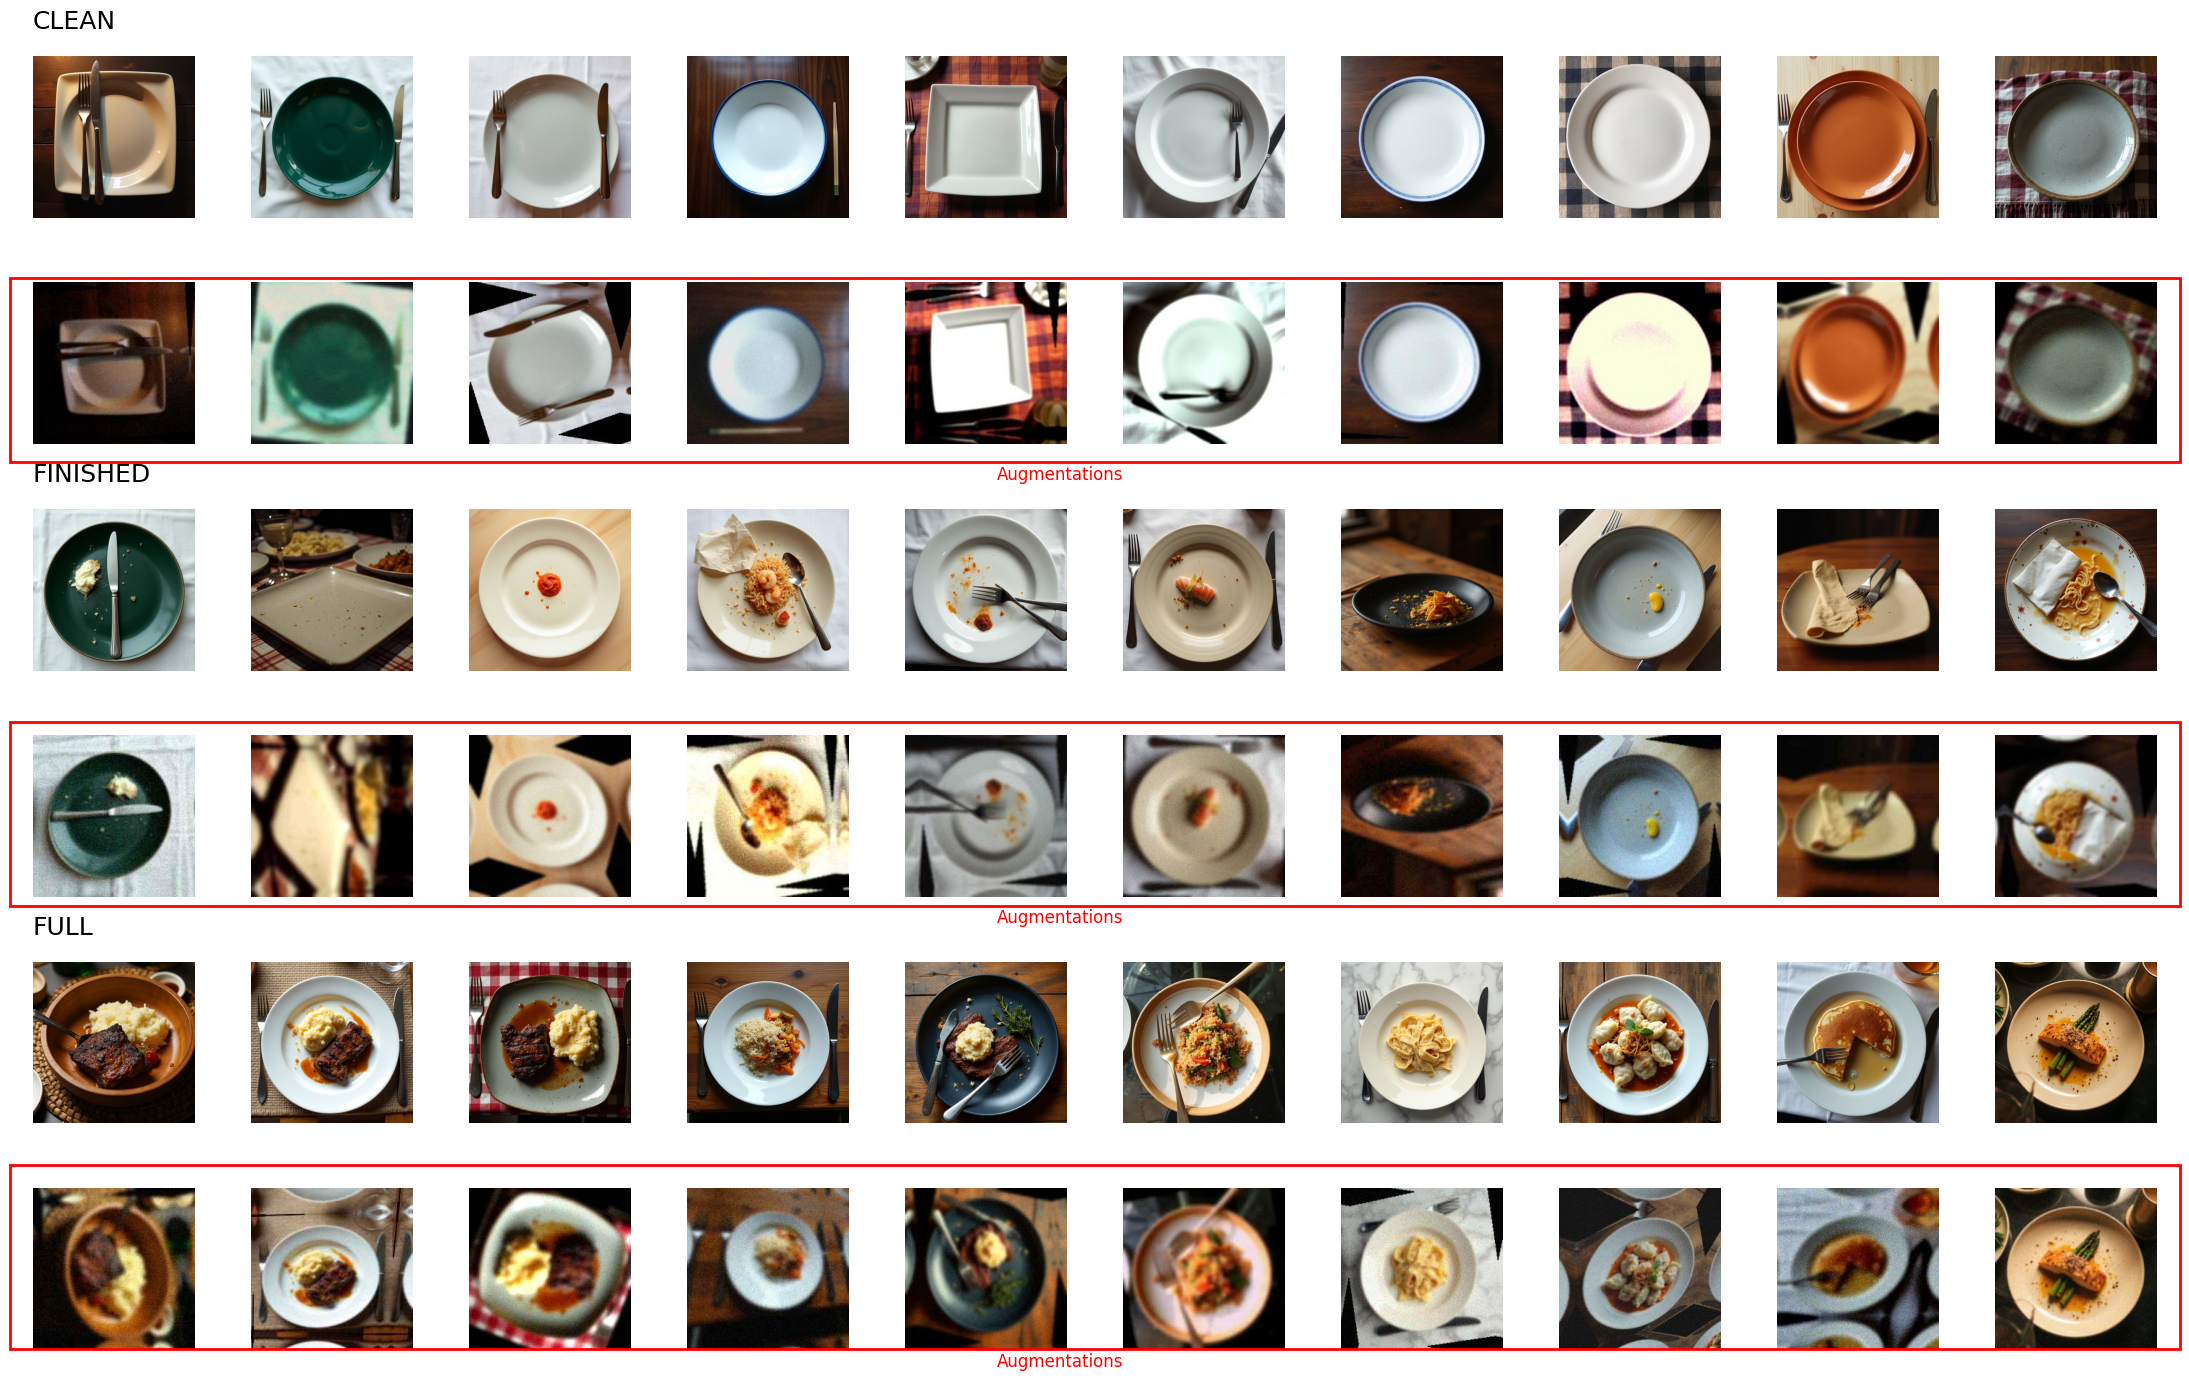

In [13]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random
from datetime import datetime

def show_all_classes(classes):

    num_classes = len(classes)
    num_images = 10  # פחות עומס!

    fig, axes = plt.subplots(
        2 * num_classes,
        num_images,
        figsize=(2.8 * num_images, 2.8 * 2 * num_classes)
    )

    for c_idx, cls in enumerate(classes):

        clean_files = list((INPUT_DIR / cls).glob("*"))[:num_images]

        for i, clean_path in enumerate(clean_files):

            img = Image.open(clean_path)

            # --- BASE ---
            axes[2*c_idx, i].imshow(img)
            axes[2*c_idx, i].axis("off")

            # --- AUG ---
            base_name = clean_path.stem
            aug_candidates = list((OUTPUT_DIR / cls).glob(f"{base_name}_aug*.jpg"))

            if len(aug_candidates) > 0:
                aug_path = random.choice(aug_candidates)
                aug_img = Image.open(aug_path)
            else:
                aug_img = img

            axes[2*c_idx + 1, i].imshow(aug_img)
            axes[2*c_idx + 1, i].axis("off")

        # 🔥 כותרת נקייה — רק פעם אחת!
        axes[2*c_idx, 0].set_title(
            cls.upper(),
            fontsize=18,
            pad=20,
            loc='left'
        )

        # =========================
        # AUGMENTATION BOX
        # =========================
        # מחשבים את גבולות השורה
        top_ax = axes[2*c_idx + 1, 0].get_position()
        bottom_ax = axes[2*c_idx + 1, -1].get_position()

        x0 = top_ax.x0
        y0 = bottom_ax.y0
        width = bottom_ax.x1 - top_ax.x0
        height = top_ax.y1 - bottom_ax.y0

        rect = Rectangle(
            (x0, y0),
            width,
            height,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        fig.add_artist(rect)

        # =========================
        # AUGMENTATION LABEL
        # =========================
        fig.text(
            0.5,
            y0 - 0.01,
            "Augmentations",
            ha='center',
            fontsize=12,
            color='red'
        )

    # 🔥 ריווח נכון
    plt.subplots_adjust(hspace=0.4, wspace=0.05)

    save_dir = "/content/drive/MyDrive/genai_project/plots"
    os.makedirs(save_dir, exist_ok=True)

    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    plt.savefig(f"{save_dir}/all_classes_aug_{timestamp}.png",
                bbox_inches="tight",
                dpi=300)

    plt.show()


show_all_classes(["clean", "finished", "full"])